# Main calculations and visualizations


Available groups: ['Amphibians', 'Mammals', 'Sharks', 'Squamates']
Cache not used or not available. Computing metrics from scratch...

=== Processing group: Amphibians ===
Amphibians: loaded 20 base trees from .\base_trees\amphibians_base_trees20.txt
[DEBUG] Amphibians / completed_multisets_amphibians_original file order (subset index -> filename):
  subset 1 -> completed_multiset_1.txt
  subset 2 -> completed_multiset_2.txt
  subset 3 -> completed_multiset_3.txt
  subset 4 -> completed_multiset_4.txt
  subset 5 -> completed_multiset_5.txt
  subset 6 -> completed_multiset_6.txt
  subset 7 -> completed_multiset_7.txt
  subset 8 -> completed_multiset_8.txt
  subset 9 -> completed_multiset_9.txt
  subset 10 -> completed_multiset_10.txt
  subset 11 -> completed_multiset_11.txt
  subset 12 -> completed_multiset_12.txt
  subset 13 -> completed_multiset_13.txt
  subset 14 -> completed_multiset_14.txt
  subset 15 -> completed_multiset_15.txt
  subset 16 -> completed_multiset_16.txt
  subset 1

,group,subset,method_key,method,median_normalized_rf,median_bsd,mean_normalized_rf,mean_bsd
0,Amphibians,1,original,Proposed,0.125000,0.278433,0.136806,0.292340
1,Amphibians,1,at_root,Root Attach,0.833333,0.348259,0.814583,0.351084
2,Amphibians,1,nearest_leaf_parent,Nearest Parent,0.833333,0.346917,0.815972,0.362470
3,Amphibians,1,no_mcs,No MCS,0.833333,0.348259,0.814583,0.351084
4,Amphibians,1,supertree,Supertree-based,0.791667,0.347563,0.783333,0.350463



Saved figure to: results\figure1_normalized_rf.svg

Saved figure to: results\figure2_bsd.svg


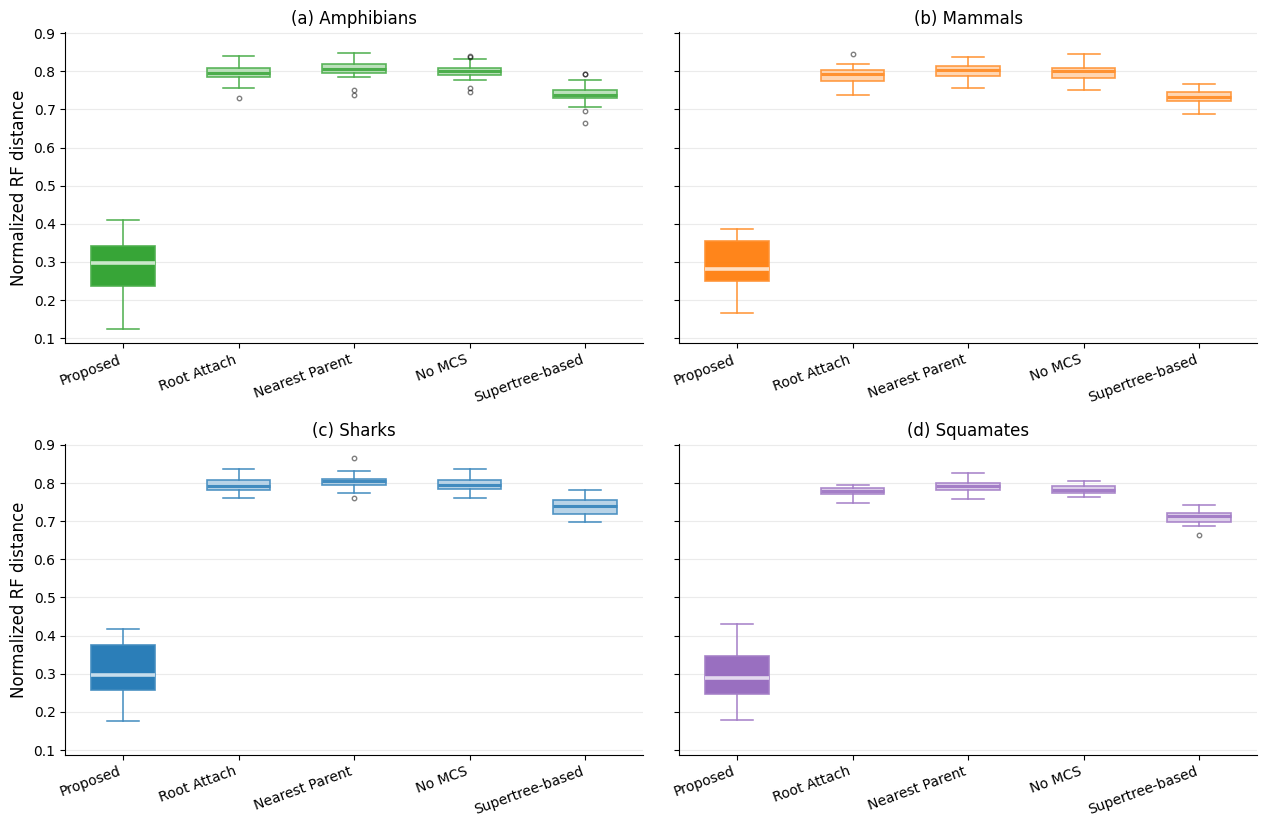

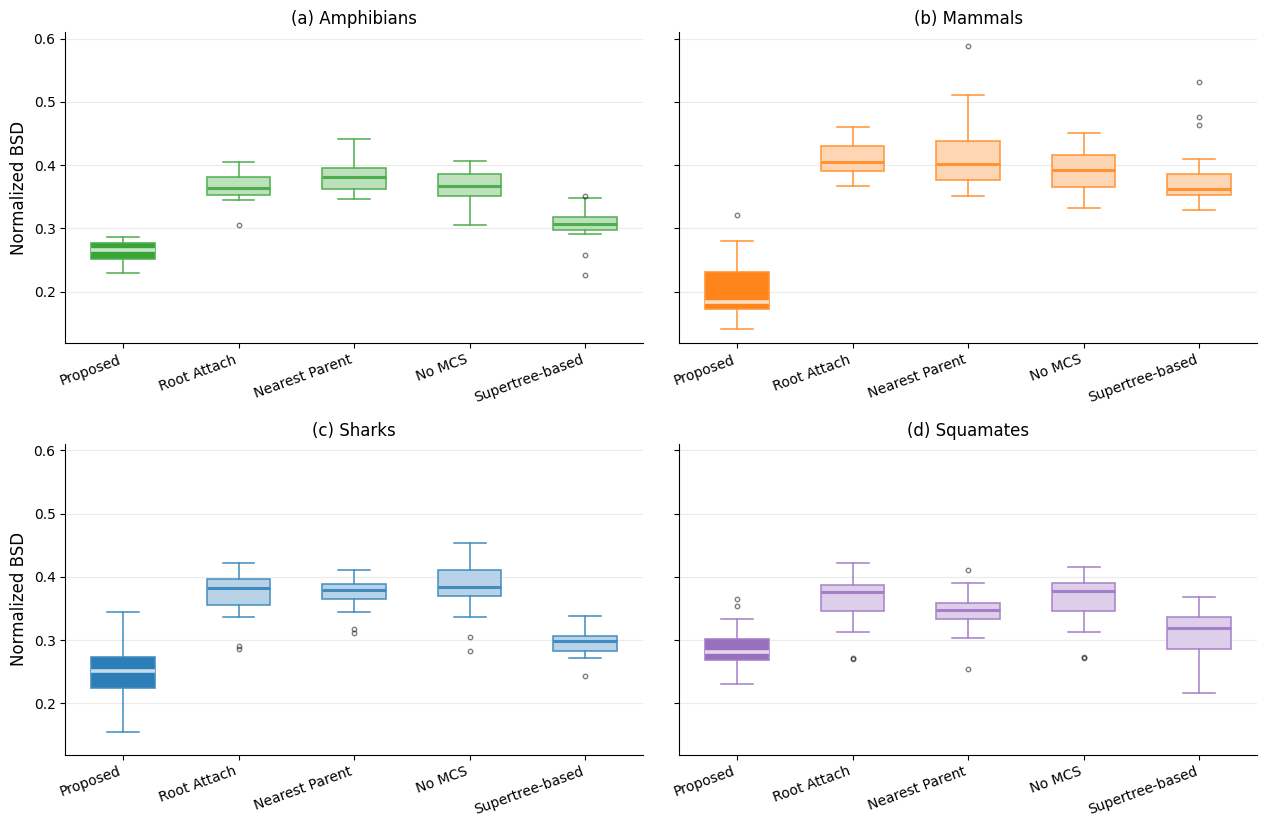

In [ ]:
# ============================================================
# Phylogenetic completion evaluation:
# Normalized RF + Normalized Branch Score Distance (BSD)
# with methods:
#   - Proposed (original)
#   - Root Attach (at_root)
#   - Nearest Parent (nearest_leaf_parent)
#   - No MCS (no_mcs)
#   - Supertree-based (supertree)
# ============================================================

import os
import glob
import math
import re
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
from ete3 import Tree
from IPython.display import display

# Config

DATA_ROOT = "."
OUTPUT_DIR = "results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

USE_CACHE_IF_AVAILABLE = True
FORCE_RECOMPUTE = False

trees_pkl_path   = os.path.join(OUTPUT_DIR, "df_trees.pkl")
subsets_pkl_path = os.path.join(OUTPUT_DIR, "df_subsets.pkl")
trees_csv_path   = os.path.join(OUTPUT_DIR, "df_trees.csv")
subsets_csv_path = os.path.join(OUTPUT_DIR, "df_subsets.csv")

# Median-based figures only
fig1_svg_path = os.path.join(OUTPUT_DIR, "figure1_normalized_rf.svg")
fig2_svg_path = os.path.join(OUTPUT_DIR, "figure2_bsd.svg")

group_configs = {
    "Amphibians": {
        "folder": "Amphibians_completed_sets",
        "base_file": os.path.join("base_trees", "amphibians_base_trees20.txt"),
        "prefix": "amphibians",
    },
    "Squamates": {
        "folder": "Squamates_completed_sets",
        "base_file": os.path.join("base_trees", "squamates_base_trees20.txt"),
        "prefix": "squamates",
    },
    "Mammals": {
        "folder": "Mammals_completed_sets",
        "base_file": os.path.join("base_trees", "mammals_base_trees20.txt"),
        "prefix": "mammals",
    },
    "Sharks": {
        "folder": "Sharks_completed_sets",
        "base_file": os.path.join("base_trees", "sharks_base_trees20.txt"),
        "prefix": "sharks",
    },
}

# Method name -> (folder_suffix, pretty_label)
methods = {
    "original": ("original", "Proposed"),
    "at_root": ("root_attach", "Root Attach"),
    "nearest_leaf_parent": ("nearest_leaf_parent", "Nearest Parent"),
    "no_mcs": ("no_mcs", "No MCS"),
    "supertree": ("supertree", "Supertree-based"),  # renamed
}

group_order = ["Amphibians", "Mammals", "Sharks", "Squamates"]
method_order = ["original", "at_root", "nearest_leaf_parent", "no_mcs", "supertree"]

panel_letters = {
    "Amphibians": "(a)",
    "Mammals": "(b)",
    "Sharks": "(c)",
    "Squamates": "(d)",
}

group_colors = {
    "Amphibians": "#2ca02c",  # green
    "Mammals": "#ff7f0e",     # orange
    "Sharks": "#1f77b4",      # blue
    "Squamates": "#9467bd",   # purple
}

PROPOSED_MEDIAN_LIGHTEN_AMOUNT = 0.75

PROPOSED_MEDIAN_LINEWIDTH = 2.6

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})


# Utility functions

def parse_newick(newick_str):
    """Parse Newick string into an ete3 Tree. Uses format=1 to keep branch lengths."""
    return Tree(newick_str, format=1)

def find_common_leaves(tree1, tree2):
    leaves1 = {leaf.name for leaf in tree1.get_leaves()}
    leaves2 = {leaf.name for leaf in tree2.get_leaves()}
    return leaves1.intersection(leaves2)

def normalized_rf_distance(tree1, tree2, common_leaves=None):
    """
    Compute normalized Robinson–Foulds distance for ROOTED trees (topology only).
    Uses only common leaves. Returns NaN if too few leaves for rooted splits.
    """
    t1 = tree1.copy()
    t2 = tree2.copy()

    if common_leaves is None:
        common_leaves = find_common_leaves(t1, t2)

    # For rooted RF, meaningful comparisons start at >= 3 leaves
    if len(common_leaves) < 3:
        return np.nan

    t1.prune(common_leaves, preserve_branch_length=True)
    t2.prune(common_leaves, preserve_branch_length=True)

    rf, max_rf, *_ = t1.robinson_foulds(
        t2,
        unrooted_trees=False,
        correct_by_polytomy_size=True
    )
    if max_rf == 0:
        return 0.0
    return rf / max_rf


def _pairwise_dist_vector(tree, leaves):
    leaves = sorted(leaves)
    return np.array([tree.get_distance(a, b) for a, b in combinations(leaves, 2)], dtype=float)

def calculate_BSD(tree1, tree2, leaves):
    """
    Branch Score Distance based on all pairwise leaf-to-leaf distances.

    Let x and y be the vectors of pairwise distances in a fixed (lexicographic) order.
      BSD = ||x - y||_2
    Normalized as:
      BSD_norm = ||x - y||_2 / ||max(x, y)||_2
    where max(x, y) is taken element-wise.
    """
    leaves = sorted(leaves)
    if len(leaves) < 2:
        return np.nan

    x = _pairwise_dist_vector(tree1, leaves)
    y = _pairwise_dist_vector(tree2, leaves)

    num = np.linalg.norm(x - y)

    m = np.maximum(x, y)          # element-wise maximum
    denom = np.linalg.norm(m)     # ||max(x,y)||_2

    return (num / denom) if denom > 0 else 0.0


def load_newick_lines(path):
    """Return a list of Newick strings (one per non-empty line)."""
    trees = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                trees.append(line)
    return trees

def extract_subset_index(path):
    """Extract numeric subset index from filename; takes the last integer in the filename."""
    base = os.path.basename(path)
    m = re.findall(r"(\d+)", base)
    if not m:
        raise ValueError(f"Could not find numeric subset index in filename: {base}")
    return int(m[-1])

def safe_nanmedian(vals, group, subset_id, method_name, metric_name):
    """Compute nanmedian but avoid warnings if all values are NaN."""
    arr = np.array(vals, dtype=float)
    finite_mask = np.isfinite(arr)
    if not finite_mask.any():
        print(f"[WARN] all NaN for {metric_name} in group={group}, subset={subset_id}, method={method_name}")
        return np.nan
    return float(np.median(arr[finite_mask]))

def safe_nanmean(vals, group, subset_id, method_name, metric_name):
    """Compute mean over finite values; warn + return NaN if none."""
    arr = np.array(vals, dtype=float)
    finite_mask = np.isfinite(arr)
    if not finite_mask.any():
        print(f"[WARN] all NaN for {metric_name} (mean) in group={group}, subset={subset_id}, method={method_name}")
        return np.nan
    return float(np.mean(arr[finite_mask]))

def detect_available_groups():
    """Determine which species groups are actually available in DATA_ROOT."""
    available = []
    for group, cfg in group_configs.items():
        base_file = os.path.join(DATA_ROOT, cfg["base_file"])
        group_dir = os.path.join(DATA_ROOT, cfg["folder"])

        if not os.path.exists(base_file):
            print(f"[INFO] Skipping group {group}: base tree file not found: {base_file}")
            continue
        if not os.path.isdir(group_dir):
            print(f"[INFO] Skipping group {group}: group directory not found: {group_dir}")
            continue

        prefix = cfg["prefix"]
        has_any_files = False
        for method_key, (suffix, _) in methods.items():
            method_dirname = f"completed_multisets_{prefix}_{suffix}"
            method_dir = os.path.join(group_dir, method_dirname)
            if glob.glob(os.path.join(method_dir, "*.txt")):
                has_any_files = True
                break

        if not has_any_files:
            print(f"[INFO] Skipping group {group}: no completed-set .txt files for any method in {group_dir}")
            continue

        available.append(group)

    return available

def get_box_data(df, group, metric_col, method_order_):
    """Returns (box_data, labels, keys) for a given group and metric."""
    data = df[df["group"] == group]
    box_data, labels, keys = [], [], []

    for m in method_order_:
        vals = data[data["method_key"] == m][metric_col].values
        vals = vals[np.isfinite(vals)]
        if len(vals) == 0:
            print(f"[INFO] No finite values for {metric_col} in group={group}, method={methods[m][1]}")
            continue
        box_data.append(vals)
        labels.append(methods[m][1])
        keys.append(m)

    return box_data, labels, keys

def lighten_color(color, amount=0.60):
    """
    Blend color toward white by 'amount' in [0,1].
      0 -> original color
      1 -> white
    """
    rgb = np.array(mcolors.to_rgb(color))
    return tuple(rgb + (1 - rgb) * amount)

def style_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.25, linewidth=0.8)
    ax.set_axisbelow(True)

def plot_metric_boxplots(df, metric_col, ylabel, fig_path, available_groups_):
    if df is None or df.empty:
        print(f"No data available for {metric_col}; skipping figure {fig_path}.")
        return None

    groups_for_plot = [
        g for g in group_order
        if g in available_groups_ and g in df["group"].unique()
    ]
    if not groups_for_plot:
        print(f"No groups with data for {metric_col}; skipping figure {fig_path}.")
        return None

    n_groups = len(groups_for_plot)
    ncols = 2 if n_groups > 1 else 1
    nrows = math.ceil(n_groups / ncols)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(6.4 * ncols, 4.2 * nrows),
        sharey=True
    )

    axes = axes.ravel() if isinstance(axes, np.ndarray) else [axes]

    for i, (ax, group) in enumerate(zip(axes, groups_for_plot)):
        style_axes(ax)

        box_data, labels, keys = get_box_data(df, group, metric_col, method_order)

        panel = panel_letters.get(group, "")
        ax.set_title(f"{panel} {group}".strip())

        if len(box_data) == 0:
            ax.set_xticks([])
            continue

        base = group_colors.get(group, "#4c78a8")
        light_box = lighten_color(base, amount=0.65)
        edge = lighten_color(base, amount=0.15)

        boxprops     = dict(linewidth=1.2)
        whiskerprops = dict(linewidth=1.1, color=edge)
        capprops     = dict(linewidth=1.1, color=edge)
        medianprops  = dict(linewidth=2.2, color=edge)
        flierprops   = dict(marker="o", markersize=3.2, alpha=0.5)

        # Matplotlib compatibility
        try:
            bp = ax.boxplot(
                box_data,
                tick_labels=labels,
                patch_artist=True,
                widths=0.55,
                showfliers=True,
                boxprops=boxprops,
                whiskerprops=whiskerprops,
                capprops=capprops,
                medianprops=medianprops,
                flierprops=flierprops,
            )
        except TypeError:
            bp = ax.boxplot(
                box_data,
                labels=labels,
                patch_artist=True,
                widths=0.55,
                showfliers=True,
                boxprops=boxprops,
                whiskerprops=whiskerprops,
                capprops=capprops,
                medianprops=medianprops,
                flierprops=flierprops,
            )

        for patch, mkey in zip(bp["boxes"], keys):
            if mkey == "original":
                patch.set_facecolor(base)
                patch.set_edgecolor(edge)
                patch.set_alpha(0.95)
            else:
                patch.set_facecolor(light_box)
                patch.set_edgecolor(edge)
                patch.set_alpha(0.90)

        for line in bp.get("whiskers", []) + bp.get("caps", []):
            line.set_color(edge)

        proposed_median_color = lighten_color(base, amount=PROPOSED_MEDIAN_LIGHTEN_AMOUNT)
        for med_line, mkey in zip(bp["medians"], keys):
            if mkey == "original":
                med_line.set_color(proposed_median_color)
                med_line.set_linewidth(PROPOSED_MEDIAN_LINEWIDTH)

        # X ticks
        ax.tick_params(axis="x", rotation=20)
        for tick in ax.get_xticklabels():
            tick.set_ha("right")

        # Only left column gets ylabel (each row’s left panel)
        is_left_col = (i % ncols == 0)
        ax.set_ylabel(ylabel if is_left_col else "")

    # Hide unused subplots
    for j in range(len(groups_for_plot), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    fig.savefig(fig_path, format="svg", bbox_inches="tight")
    print(f"\nSaved figure to: {fig_path}")
    return fig


# Determine which groups are available in DATA_ROOT

available_groups = detect_available_groups()
processing_groups = [g for g in group_order if g in available_groups]
print("\nAvailable groups:", processing_groups)


# Either compute metrics or load from cache

df_trees = None
df_subsets = None

if USE_CACHE_IF_AVAILABLE and not FORCE_RECOMPUTE \
   and os.path.exists(trees_pkl_path) and os.path.exists(subsets_pkl_path):
    print("Loading cached results from PKL files...")
    df_trees = pd.read_pickle(trees_pkl_path)
    df_subsets = pd.read_pickle(subsets_pkl_path)
    print("Loaded:")
    print("  ", trees_pkl_path)
    print("  ", subsets_pkl_path)

    if processing_groups:
        df_trees = df_trees[df_trees["group"].isin(processing_groups)]
        df_subsets = df_subsets[df_subsets["group"].isin(processing_groups)]

    # If mean columns are missing, compute them from df_trees
    if df_subsets is not None and df_trees is not None:
        if "mean_normalized_rf" not in df_subsets.columns or "mean_bsd" not in df_subsets.columns:
            print("Cached df_subsets has no mean columns. Computing mean_normalized_rf and mean_bsd from df_trees...")

            def nanmean_or_nan(x):
                arr = np.array(x, dtype=float)
                arr = arr[np.isfinite(arr)]
                if len(arr) == 0:
                    return np.nan
                return float(np.mean(arr))

            grouped = df_trees.groupby(["group", "subset", "method_key", "method"])
            mean_df = grouped.agg(
                mean_normalized_rf=("normalized_rf", nanmean_or_nan),
                mean_bsd=("bsd", nanmean_or_nan),
            ).reset_index()

            df_subsets = df_subsets.merge(
                mean_df,
                on=["group", "subset", "method_key", "method"],
                how="left",
                suffixes=("", "_from_trees")
            )

            df_subsets.to_pickle(subsets_pkl_path)
            df_subsets.to_csv(subsets_csv_path, index=False)
            print("Updated df_subsets with mean columns and re-saved cache.")
else:
    print("Cache not used or not available. Computing metrics from scratch...")

    results_per_tree = []
    subset_medians = []

    for group in processing_groups:
        cfg = group_configs[group]
        print(f"\n=== Processing group: {group} ===")
        group_dir = os.path.join(DATA_ROOT, cfg["folder"])
        base_file = os.path.join(DATA_ROOT, cfg["base_file"])
        prefix = cfg["prefix"]

        base_newicks = load_newick_lines(base_file)
        print(f"{group}: loaded {len(base_newicks)} base trees from {base_file}")
        if len(base_newicks) != 20:
            print(f"WARNING: {group} base trees file has {len(base_newicks)} trees (expected 20).")

        method_to_files = {}
        for method_key, (suffix, pretty_name) in methods.items():
            method_dirname = f"completed_multisets_{prefix}_{suffix}"
            method_dir = os.path.join(group_dir, method_dirname)

            files = glob.glob(os.path.join(method_dir, "*.txt"))
            if not files:
                print(f"WARNING: no .txt files found in {method_dir}")
                method_to_files[method_key] = []
                continue

            files = sorted(files, key=extract_subset_index)

            if group == "Amphibians" and method_key == "original":
                print(f"[DEBUG] {group} / {method_dirname} file order (subset index -> filename):")
                for f in files:
                    print(f"  subset {extract_subset_index(f)} -> {os.path.basename(f)}")

            if len(files) != 20:
                print(f"WARNING: {group} / {method_dirname} has {len(files)} .txt files (expected 20).")

            method_to_files[method_key] = files

        nonempty = [files for files in method_to_files.values() if files]
        if not nonempty:
            print(f"[ERROR] No completed-set files found for group {group}. Skipping.")
            continue

        num_subsets = min(len(base_newicks), min(len(files) for files in nonempty))
        print(f"{group}: will process {num_subsets} subsets")

        for subset_idx in range(num_subsets):
            subset_id = subset_idx + 1
            print(f"{group}: starting subset {subset_id}/{num_subsets}")

            base_tree = parse_newick(base_newicks[subset_idx])

            subset_method_rf = {}
            subset_method_bsd = {}
            subset_method_mean_rf = {}
            subset_method_mean_bsd = {}

            for method_key, (_, pretty_name) in methods.items():
                file_list = method_to_files.get(method_key, [])
                if subset_idx >= len(file_list):
                    print(f"[WARN] Missing completed set for group={group}, subset={subset_id}, method={pretty_name}")
                    continue

                completed_file = file_list[subset_idx]
                completed_newicks = load_newick_lines(completed_file)

                if len(completed_newicks) == 0:
                    print(f"[WARN] Empty completed set: group={group}, subset={subset_id}, method={pretty_name}, file={completed_file}")
                    continue

                rf_values, bsd_values = [], []
                print(f"  {group}:  subset {subset_id}, method {pretty_name} -> {len(completed_newicks)} trees")

                for tree_idx, newick_str in enumerate(completed_newicks):
                    completed_tree = parse_newick(newick_str)
                    common_leaves = find_common_leaves(base_tree, completed_tree)

                    nrf = normalized_rf_distance(base_tree, completed_tree, common_leaves)
                    bsd = calculate_BSD(base_tree, completed_tree, common_leaves) if len(common_leaves) >= 2 else np.nan

                    rf_values.append(nrf)
                    bsd_values.append(bsd)

                    results_per_tree.append({
                        "group": group,
                        "subset": subset_id,
                        "method_key": method_key,
                        "method": pretty_name,
                        "tree_idx": tree_idx + 1,
                        "normalized_rf": nrf,
                        "bsd": bsd,
                    })

                subset_method_rf[method_key] = safe_nanmedian(rf_values, group, subset_id, pretty_name, "normalized_rf")
                subset_method_bsd[method_key] = safe_nanmedian(bsd_values, group, subset_id, pretty_name, "bsd")
                subset_method_mean_rf[method_key] = safe_nanmean(rf_values, group, subset_id, pretty_name, "normalized_rf")
                subset_method_mean_bsd[method_key] = safe_nanmean(bsd_values, group, subset_id, pretty_name, "bsd")

            for method_key, (_, pretty_name) in methods.items():
                if method_key not in subset_method_rf:
                    continue
                subset_medians.append({
                    "group": group,
                    "subset": subset_id,
                    "method_key": method_key,
                    "method": pretty_name,
                    "median_normalized_rf": subset_method_rf[method_key],
                    "median_bsd": subset_method_bsd[method_key],
                    "mean_normalized_rf": subset_method_mean_rf[method_key],
                    "mean_bsd": subset_method_mean_bsd[method_key],
                })

            print(f"{group}: finished subset {subset_id}/{num_subsets}")

    df_trees = pd.DataFrame(results_per_tree)
    df_subsets = pd.DataFrame(subset_medians)

    df_trees.to_pickle(trees_pkl_path)
    df_subsets.to_pickle(subsets_pkl_path)
    df_trees.to_csv(trees_csv_path, index=False)
    df_subsets.to_csv(subsets_csv_path, index=False)

    print("\nSaved DataFrames to:")
    print("  ", trees_pkl_path)
    print("  ", subsets_pkl_path)
    print("  ", trees_csv_path)
    print("  ", subsets_csv_path)


print("\nPer-subset medians/means (first few rows):")
if df_subsets is not None and not df_subsets.empty:
    display(df_subsets.head())
else:
    print("df_subsets is empty; nothing to display.")


# Figure 1: Normalized RF distance boxplots

plot_metric_boxplots(
    df_subsets,
    metric_col="median_normalized_rf",
    ylabel="Normalized RF distance",
    fig_path=fig1_svg_path,
    available_groups_=processing_groups,
)



# Figure 2: Normalized BSD boxplots

plot_metric_boxplots(
    df_subsets,
    metric_col="median_bsd",
    ylabel="Normalized BSD",
    fig_path=fig2_svg_path,
    available_groups_=processing_groups,
)

plt.show()